# Comparison among Optimization Algorithms

Hello there, in this notebook I present the results about the use of:
* Differential Evolution
* Direct
* Basin-Hopping with SLSCP

All of these algorithm have a non linear constrain over the refractive index $n(\lambda)$:
$$ 1.8 \leq n(\lambda) \leq 2.1 $$
And bounds in each parameter.

## Used libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import time 
import numpy as np

In [2]:
from fpdf import FPDF

In [3]:
pdf = FPDF(orientation='P', unit='mm', format='A4')

In [4]:
pdf.add_page()

In [5]:
pdf.set_font('Arial', 'B', 16)

In [6]:
pdf.multi_cell(
    0, 
    10, 
    'Comparación entre Algoritmos de Optimización para el Ajuste de Espectros de Transmitancia dentro del Modelo de Alonso et al', 
    border=1, 
    #ln=1, 
    align='C')

[]

In [7]:
pdf.ln(10)

## Load results

In [8]:
pdf.set_font('Times', '', 12)
intro_text = """Dentro el modelo de Transmitancia de Alonso et al, el espectro de transmitancia es función de 13 parámetros: 

1. Longitud de onda.
2. Espesor [nm]
3. Rugosidades R1, R2. 
4. Coeficientes de Sellmeier [A,B,C,D,E].
5. Parámetros de Absorción [Alpha, Beta, LambdaG].
6. Número de portadores de carga Ne. 

A partir del espectro de transmitancia puede obtenerse, mediante el método de Máximos y Mínimos, una primer aproximación al valor del espesor. Esta primer aproximación es empleada como un valor semilla, a partir del cual se refina posteriormente. 

En este breve informe, presentamos una comparativa entre los siguientes algoritmos de optimización: 

1. Direct
2. Basin-Hopping
3. Differential Evolution

Para la determinación de aquellos parámetros que modelen con el menor MSE el espectro experimental. Se ajustaron 145 muestras experimentales. 
"""
pdf.multi_cell(0, 5, intro_text)
pdf.ln(10) # Add a 10mm break

In [9]:
direct = np.load('../../results/SciPy_IIM/direct_NonLinear_145F.npy')[:, -1]
direct.shape

(145,)

In [10]:
bh = np.load('../../results/SciPy_IIM/basin_hopping_NonLinear_145F.npy')[:, -1]
bh.shape

(145,)

In [11]:
de = np.load('../../results/SciPy_IIM/differential_evolution_NonLinear_145F.npy')[:, -1]
de.shape

(145,)

## Seaborn parameters

In [12]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges
    "axes.grid": False,           # Turn off grid completely

})

## Raw Comparison

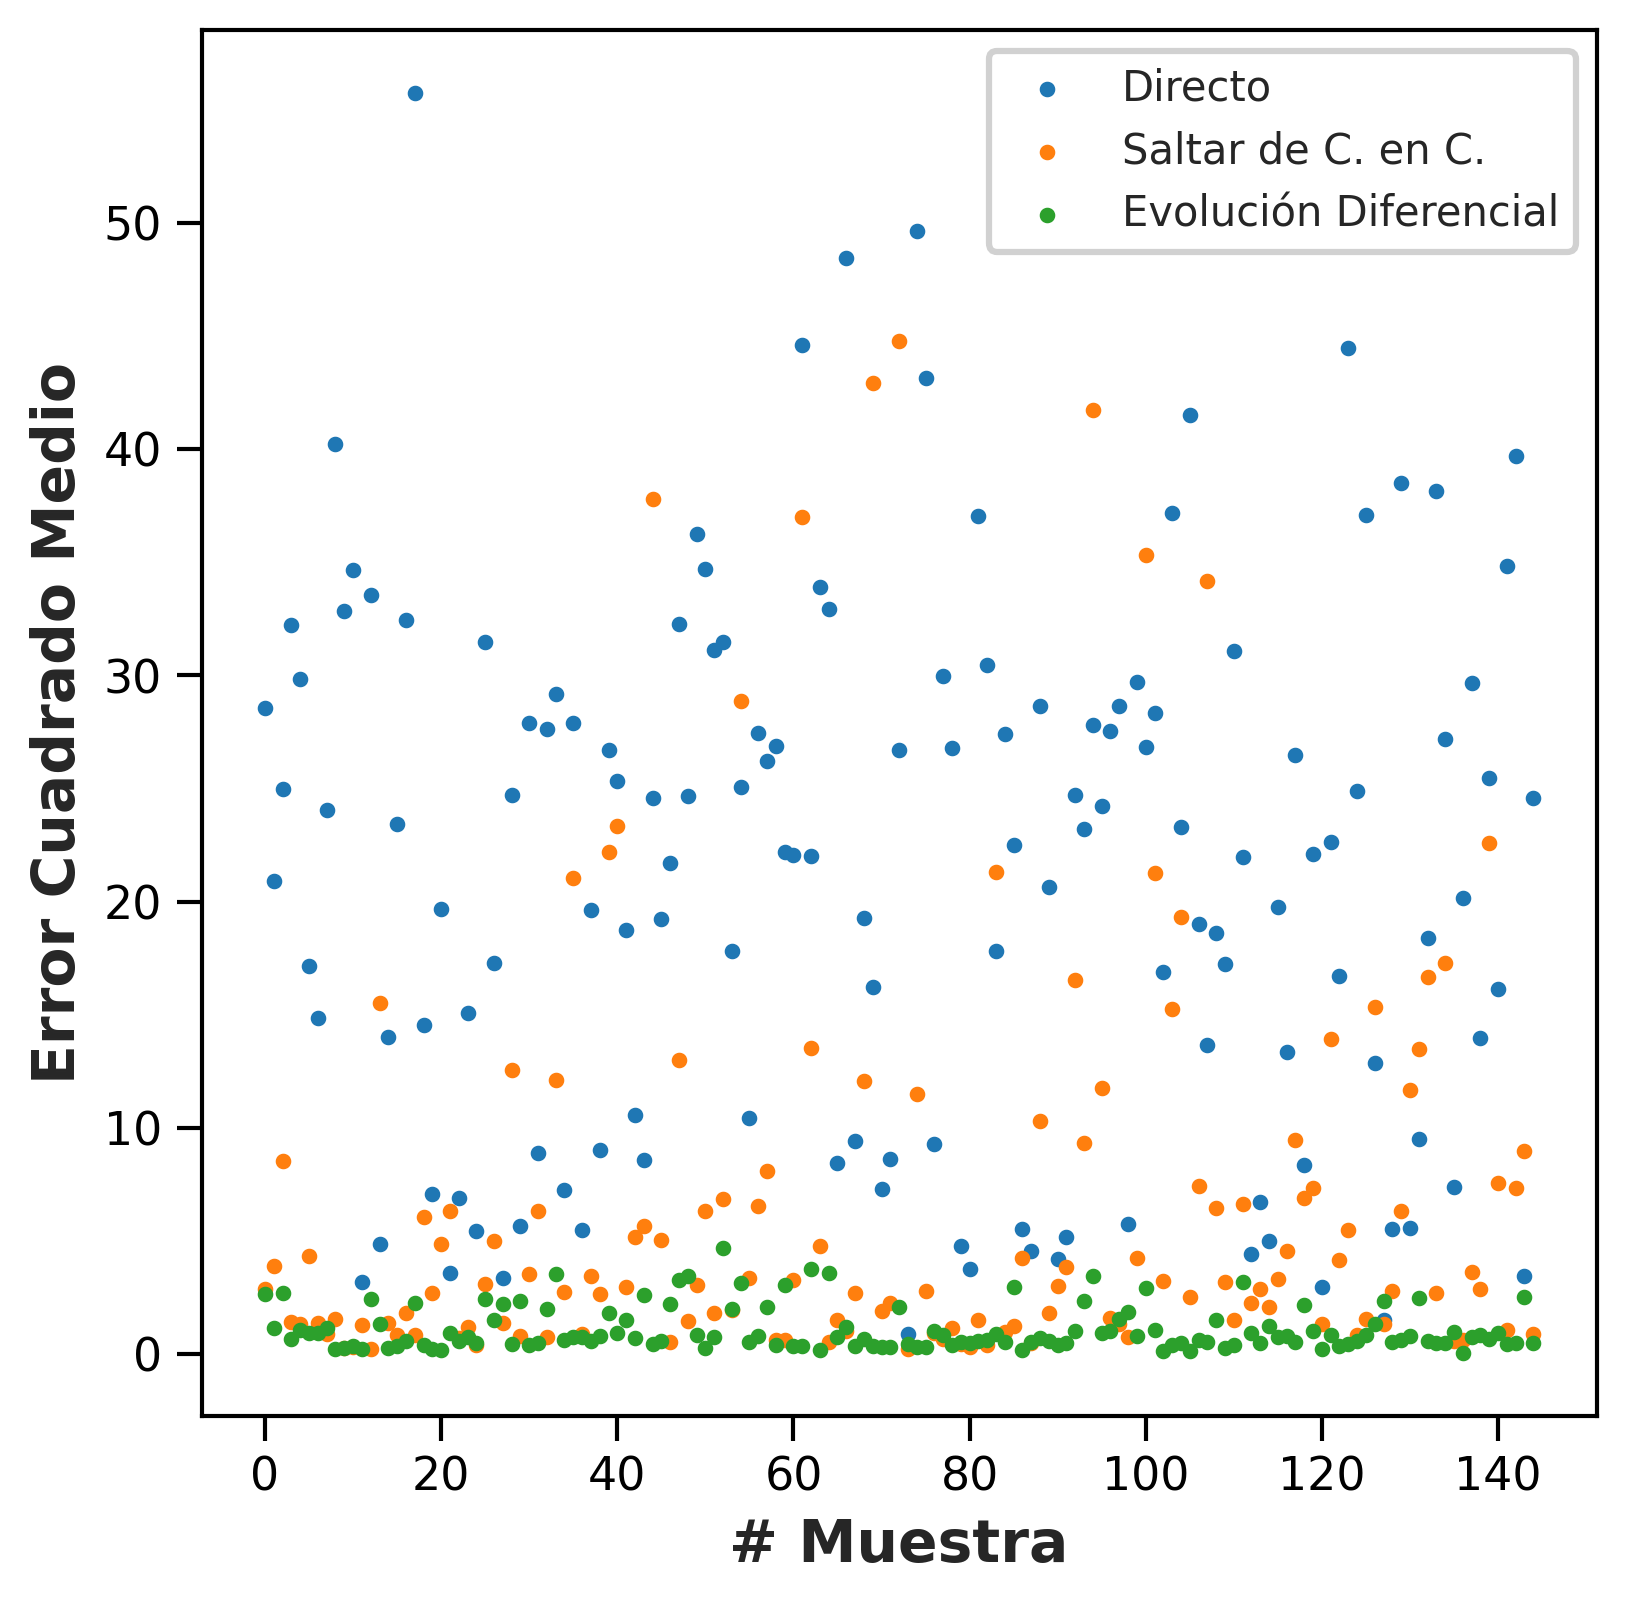

In [13]:
plt.figure(figsize = (6,6))
x = [x for x in range(0, direct.shape[0])]
s = 5
plt.scatter(x, direct, label = 'Directo', s=s)
plt.scatter(x, bh, label = 'Saltar de C. en C.', s=s)
plt.scatter(x, de, label = 'Evolución Diferencial', s=s)
plt.legend()
#plt.grid()
#plt.title('Error en el ajuste para cada muestra')
plt.xlabel('# Muestra')
plt.ylabel('Error Cuadrado Medio')
plt.savefig('./images/comparative.png')
plt.show()

In [14]:
pdf.set_font('Times', '', 12)
intro_text = """A continuación se presenta el valor de MSE ó Error Cuadrado Medio para cada una de las 161 muestras empleadas. Podemos observar que el mejor ajuste se obtiene mediante el uso del optimizador: Differential Evolution. Errores considerables se obtiene al considerar el algoritmo Direct y Basin-Hopping."""
pdf.multi_cell(0, 5, intro_text)
#pdf.ln(10) # Add a 10mm break

[]

In [15]:
pdf.image('./images/comparative.png', x=60, w=90)

## KDE Estimation

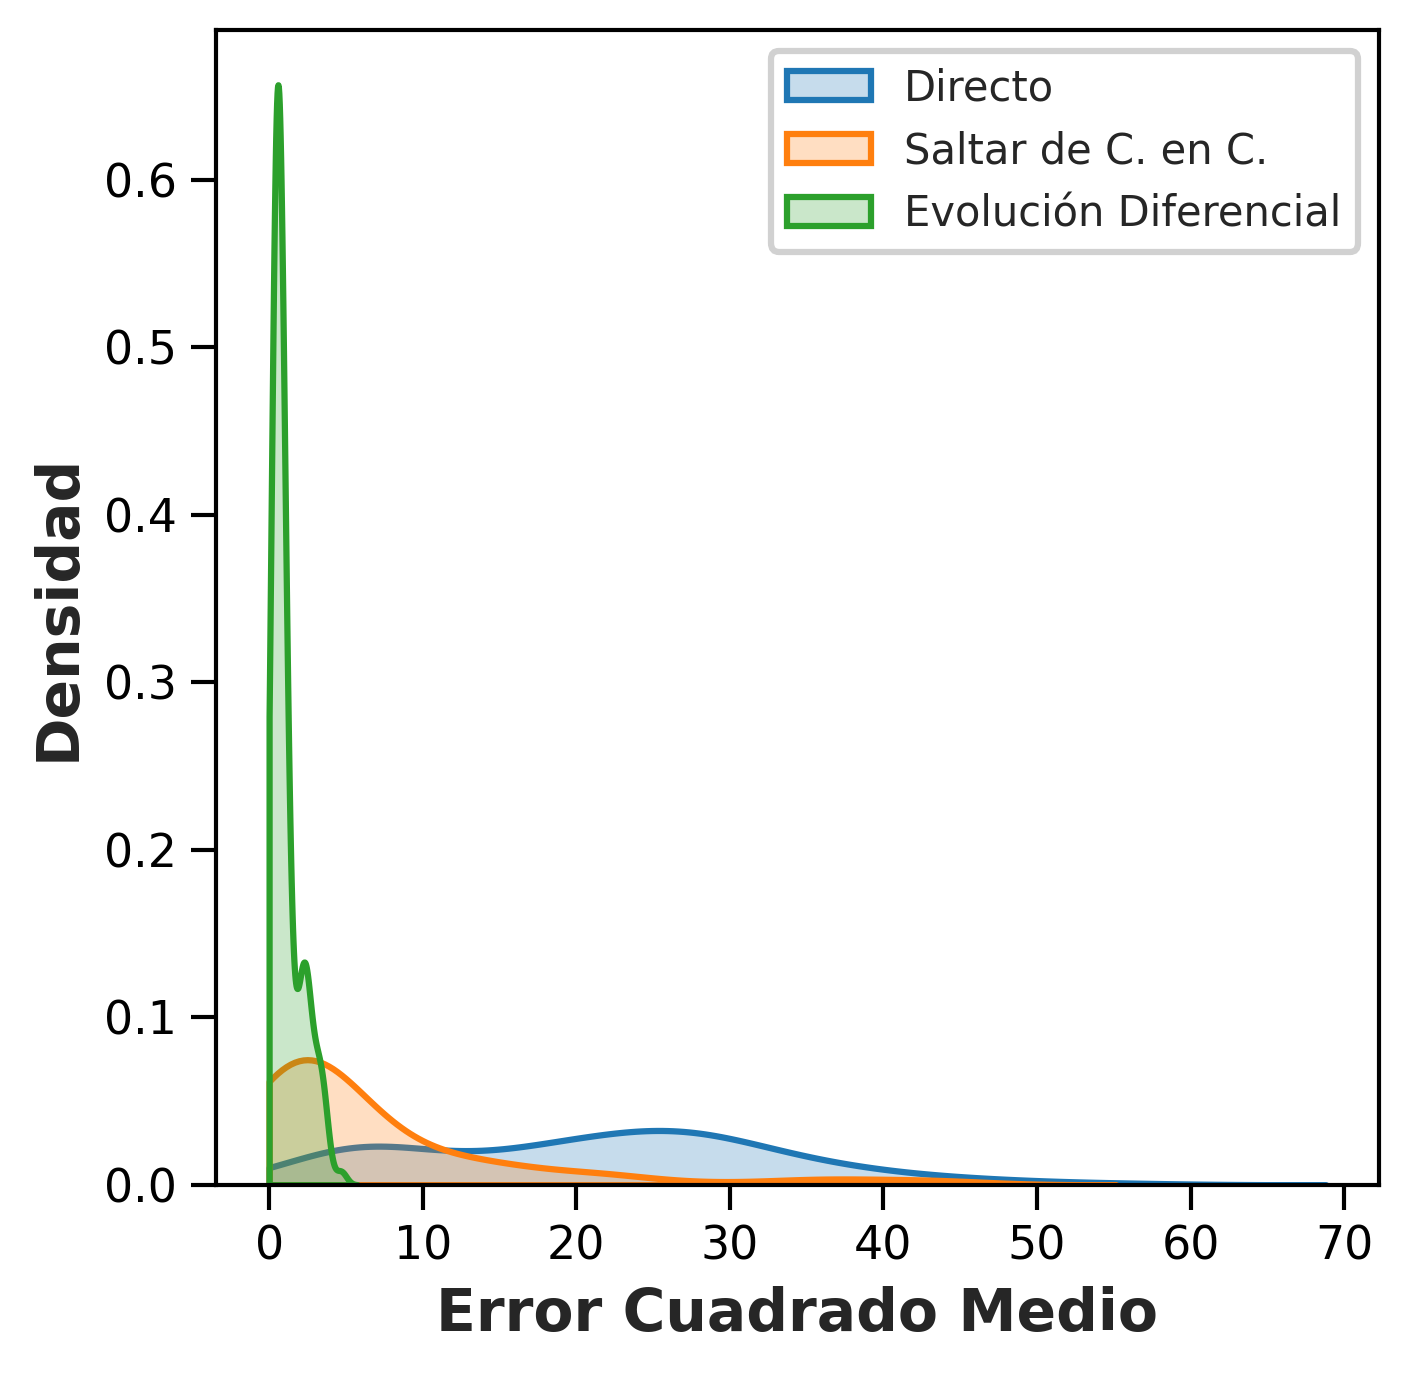

In [16]:
plt.figure(figsize = (5,5))
sns.kdeplot(direct, label = 'Directo', fill = True, clip = [0, np.inf])
sns.kdeplot(bh, label = 'Saltar de C. en C.', fill = True, clip = [0, np.inf])
sns.kdeplot(de, label = 'Evolución Diferencial', fill = True, clip = [0, np.inf])
plt.legend()
#plt.grid()
#plt.title('Estimación de Densidad de Kernel del Error')
plt.xlabel('Error Cuadrado Medio')
plt.ylabel('Densidad')
plt.savefig('./images/kde_optimizers.png')
plt.show()

In [17]:
pdf.set_font('Times', '', 12)
intro_text = """A continuación se presenta la Estimación de Densidad (PDF) del Error Cuadrado Medio para cada optimizador. En ésta comparativa se aprecia como el optimizador: Differential Evolution presenta los mejores resultados al estar su distribución de densidad centrada en un valor cercano a 0. En cambio el optimizador de Basin-Hopping presenta un compartamiento similar a una distribución normal centrada en 5, mientras que el optimizador Direct presenta un comportamiento similar "a groso modo" a una distribución uniforme o, de manera más precisa, a una super-posición de distribuciones normales centradas en 8 y en 30."""
pdf.multi_cell(0, 5, intro_text)
#pdf.ln(10) # Add a 10mm break

[]

In [18]:
pdf.image('./images/kde_optimizers.png', x=60, w=90)

## Comparison

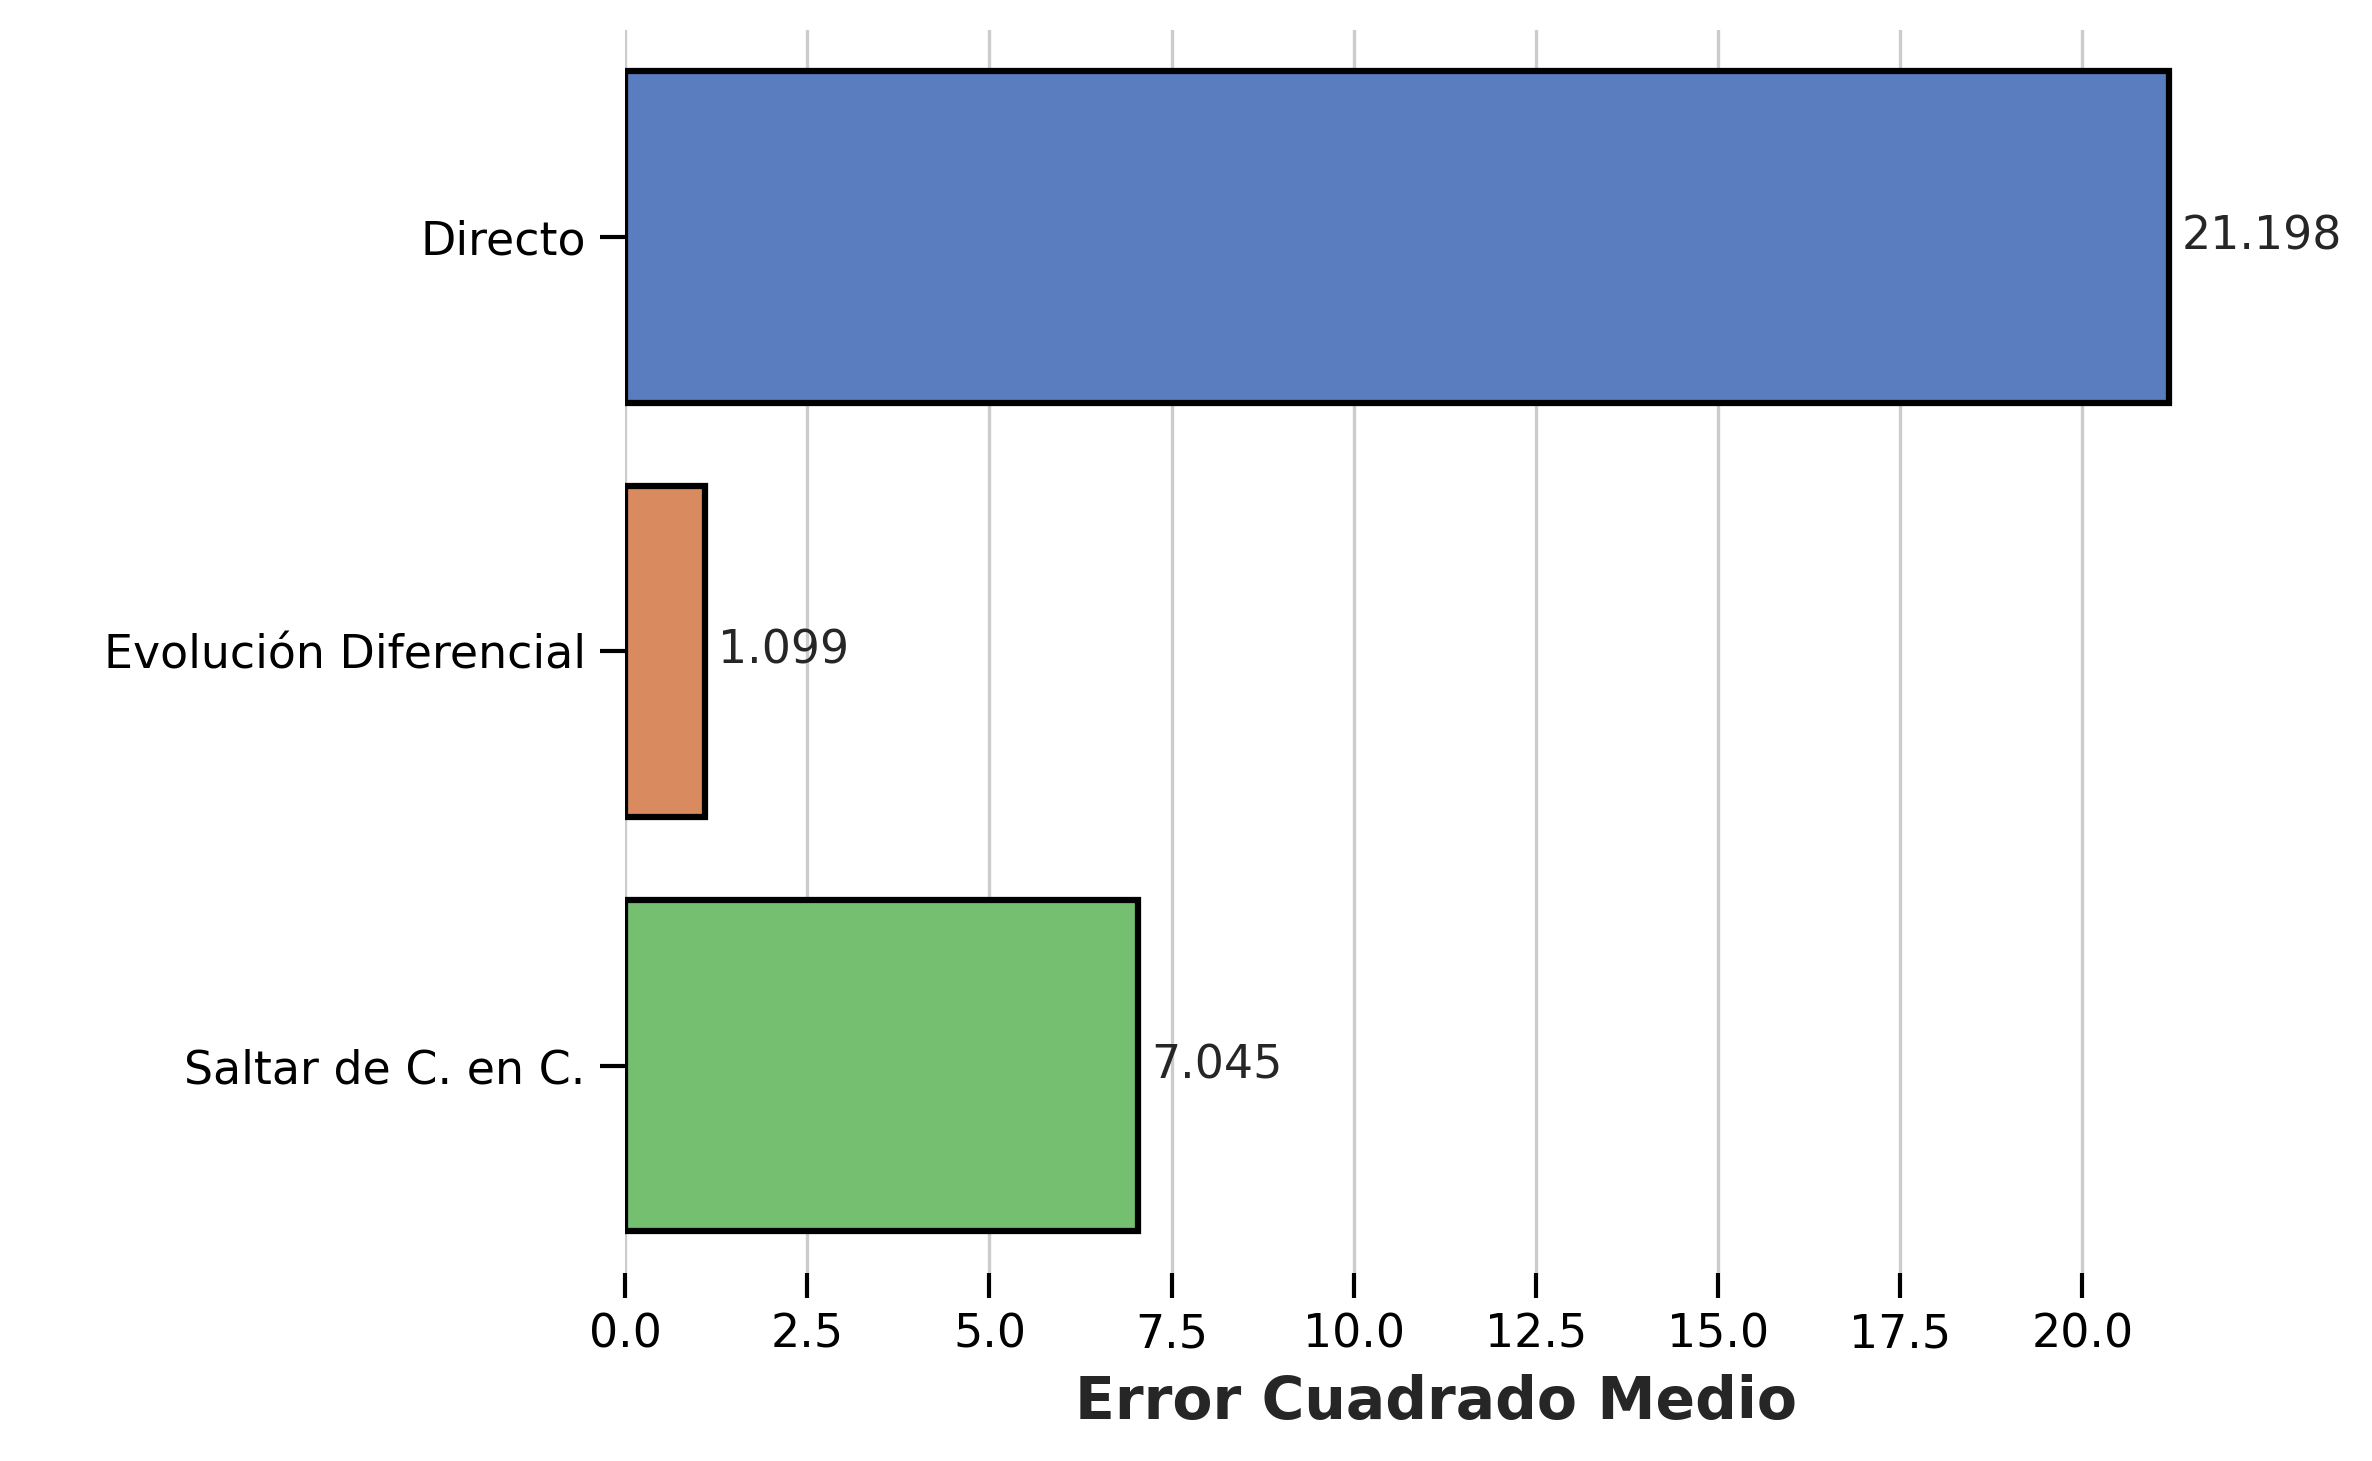

In [19]:
df = pd.DataFrame({
    'Directo': direct, 
    'Evolución Diferencial': de, 
    'Saltar de C. en C.': bh
})

# Set Seaborn style
#sns.set_theme(style="whitegrid", font_scale=1.1)

# Create horizontal bar plot
plt.figure(figsize=(8, 5))
plt.grid(True)
ax = sns.barplot(
    data=df,
    palette="muted",
    orient="h",
    errorbar= None
)

# Improve aesthetics
#ax.set_title("Comparación entre Optimizadores Globales", fontsize=14, weight="bold")
ax.set_xlabel("Error Cuadrado Medio")
ax.set_ylabel(" ")
sns.despine(left=True, bottom=True)

# Move legend to a clean position
#ax.legend(title="", loc="lower right", frameon=False)

# Annotate bars with values
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=3)

plt.tight_layout()
plt.savefig('./images/final_comparative.png')
plt.show()

In [20]:
pdf.set_font('Times', '', 12)
intro_text = """A continuación se presenta una comparativa del valor promedio del Error Cuadrado Medio de cada optimizador empleado. Los resultados sugieren que el optimizador: Differential Evolution obtiene el menor Error Cuadrado Medio para cada una de las muestras. Este optimizador es seguido por Basin-Hopping y Direct. 

El error que presenta Direct es significativo en magnitud y, pese al poco tiempo de ejecución (5 minutos), no se recomienda para el ajuste de de los espectros. El tiempo requerido es Basin-Hopping es significativamente mayor (12 horas) en el ajuste de las 161 muestras. En cambio Differential Evolution posee un tiempo promedio de 4 horas. 

"""
pdf.multi_cell(0, 5, intro_text)
pdf.ln(10) # Add a 10mm break

In [21]:
pdf.output('comparativa_optimizadores.pdf')

''

## Obtencion de Ng

In [22]:
df = pd.read_csv('../../experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
t_v = df.values

In [23]:
t_v.shape

(911, 2)

In [24]:
def ng_f(t_v):
    """
    t_v transmitancia del vidrio
    """
    return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

In [25]:
ng = ng_f(t_v[:,1])

In [26]:
np.min(ng), np.max(ng)

(np.float64(1.5269215605040498), np.float64(66666.66665166666))

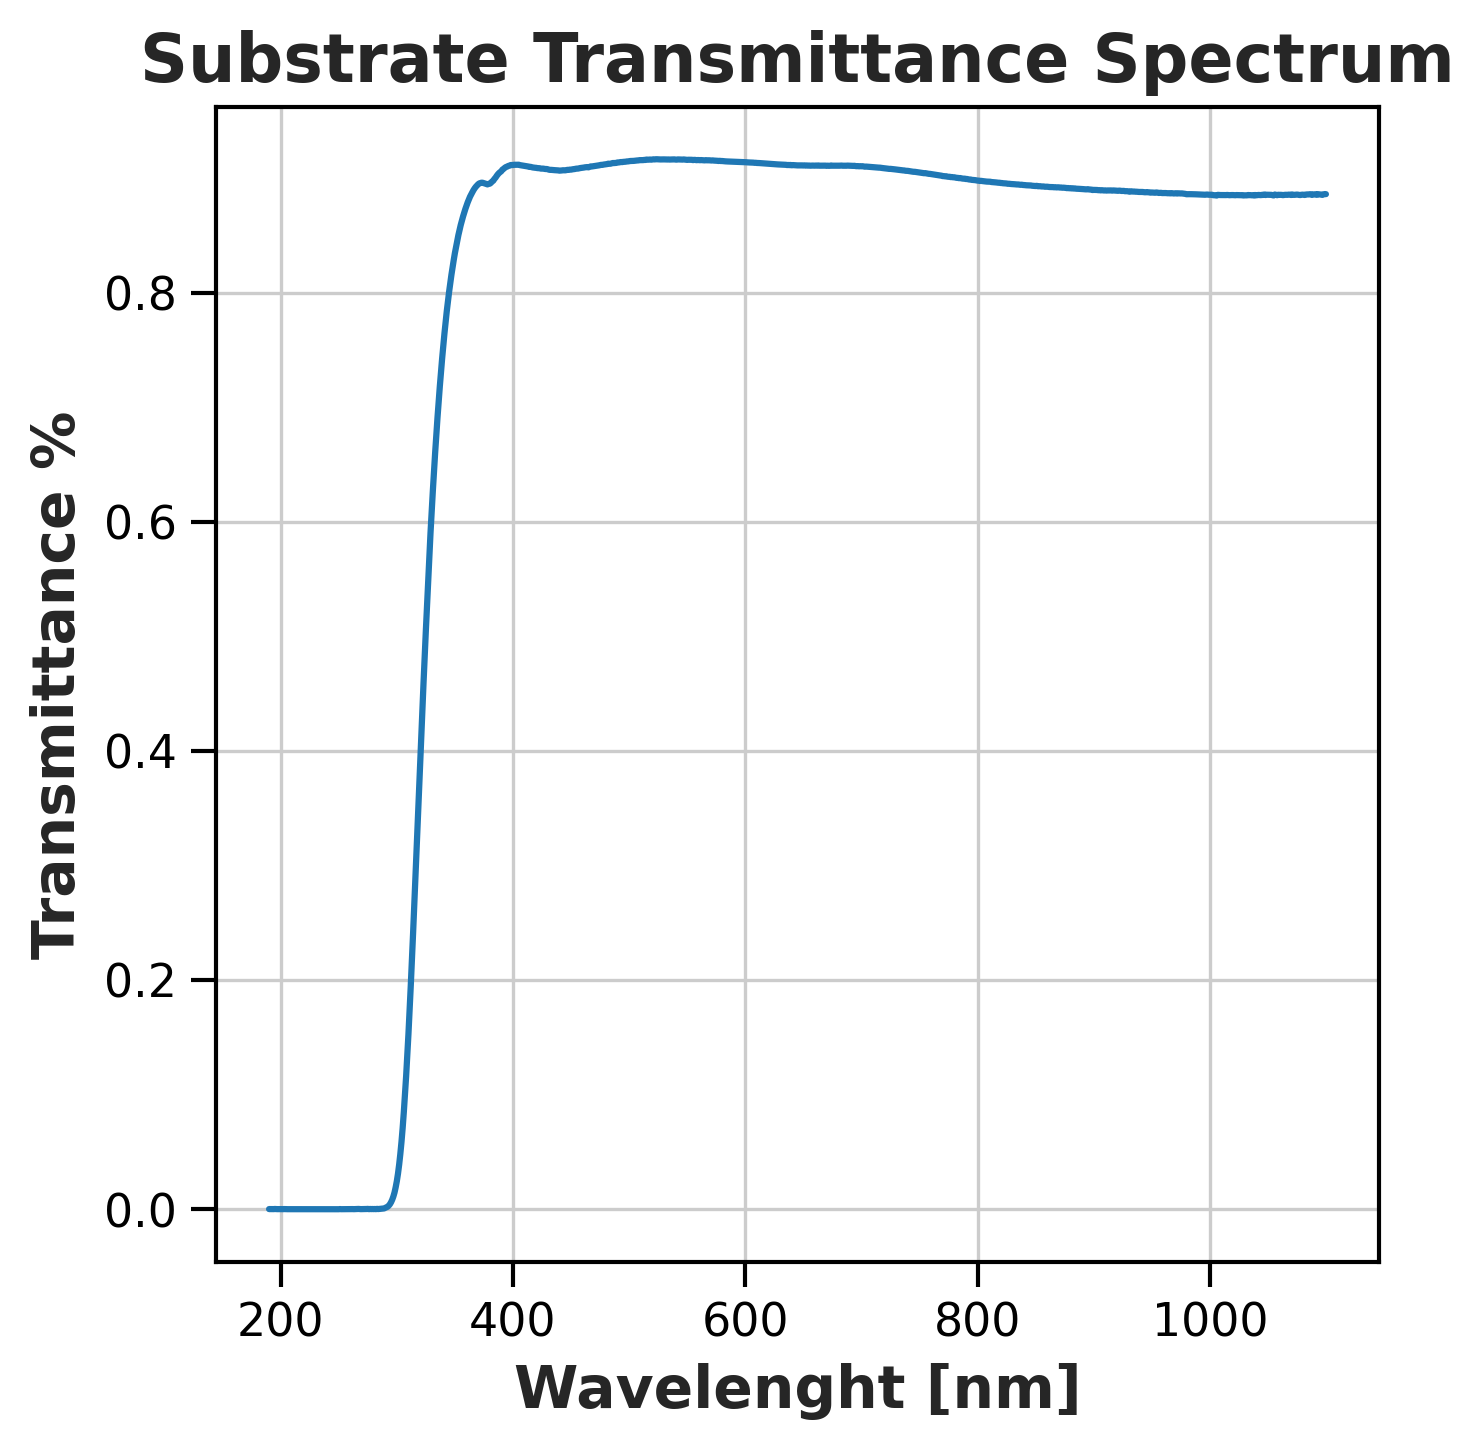

In [27]:
plt.figure(figsize = (5,5))
plt.title('Substrate Transmittance Spectrum')
plt.ylabel('Transmittance %')
plt.xlabel('Wavelenght [nm]')
plt.plot(t_v[:,0], t_v[:,1])
plt.grid()
plt.show()

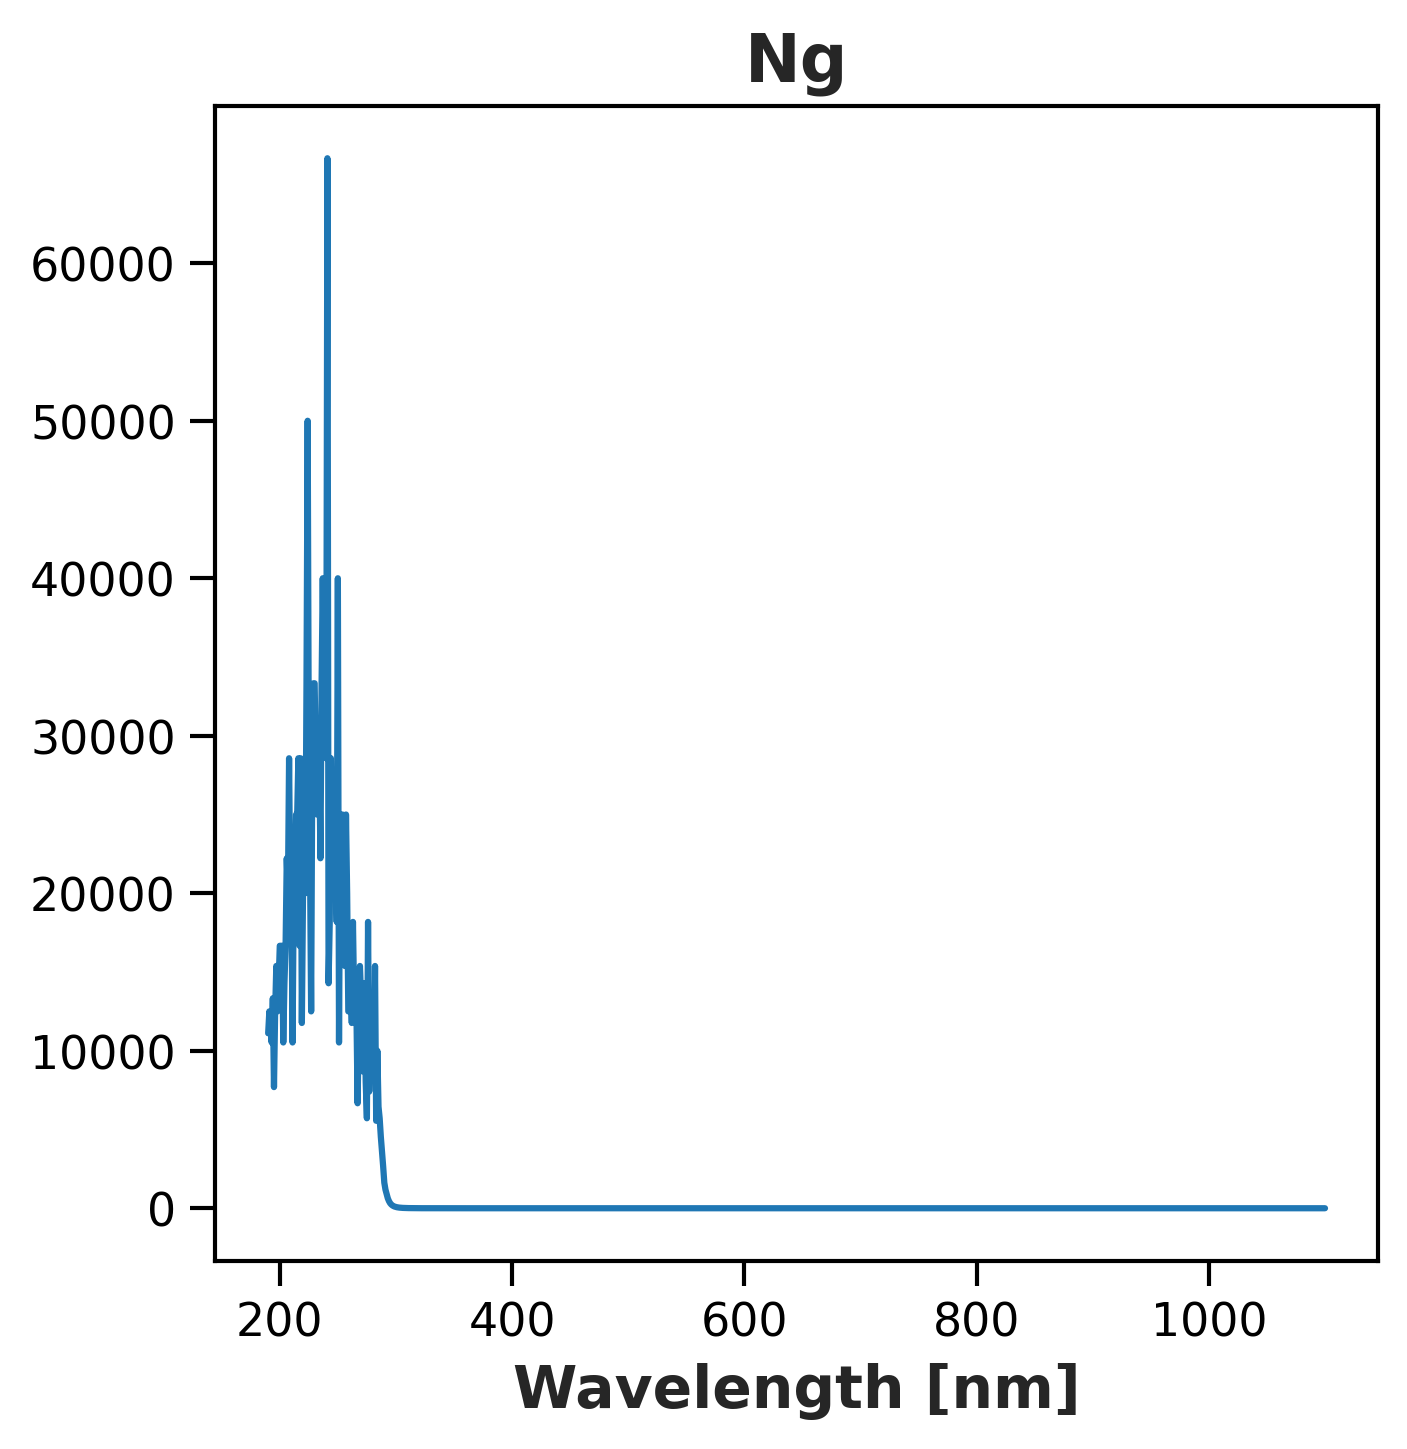

In [28]:
plt.figure(figsize = (5,5))
plt.plot(t_v[:,0], ng)
plt.title('Ng')
plt.xlabel('Wavelength [nm]')
plt.show()